In [1]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

SEED = 42

BATCH_SIZE = 32
HEIGHT, WIDTH = 224, 224

C:\Users\zabeeh\PycharmProjects\DeepLearning\v_general\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0, GPU: False


# Visualzing dataset

C:\Users\zabeeh\PycharmProjects\DeepLearning\CompleteProjects\PneumoniaDetection\data\chest_xray\train\NORMAL\IM-0115-0001.jpeg
tf shape (1858, 2090, 1) and dtype <dtype: 'uint8'>
cv2 shape (1858, 2090, 3) and dtype  uint8 
reize image dimesnion  (224, 224, 3)


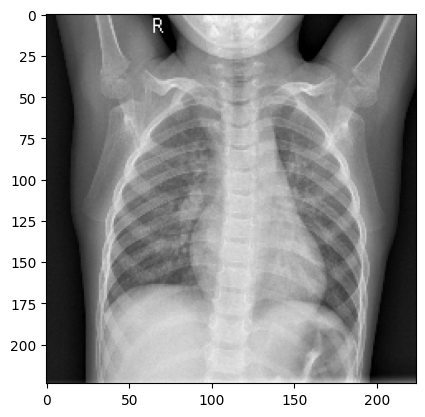

cv2 img resized shape (224, 224, 3) and dtype  uint8 


In [11]:
import os, cv2
import glob
import matplotlib.pyplot as plt

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')

path = glob.glob(os.path.join(TRAIN_DIR, '**', '*.jpeg'), recursive=True)[0]
print(path)

img = tf.image.decode_image(tf.io.read_file(path))
print("tf shape {} and dtype {}".format(img.shape, img.dtype))

img = cv2.imread(str(path))
print("cv2 shape {} and dtype  {} ".format(img.shape, img.dtype))

img_resized = cv2.resize(img, (HEIGHT, WIDTH))
plt.imshow(img_resized)
print("reize image dimesnion ",img_resized.shape)
plt.show()
print("cv2 img resized shape {} and dtype  {} ".format(img_resized.shape, img_resized.dtype))

In [39]:
TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')
VALIDATION_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

loaded_training_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, shuffle=True, seed=SEED, image_size=(HEIGHT, WIDTH),
    # color_mode='grayscale',       #converts chaneel =1
    batch_size=BATCH_SIZE, label_mode='int')

for images, labels in loaded_training_dataset.take(1):
    print(f"loaded_training_dataset image shape {images.shape} and labels shape {labels.shape}")

loaded_validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR, shuffle=False, seed=SEED, image_size=(HEIGHT, WIDTH),
    # color_mode='grayscale',
    batch_size=BATCH_SIZE, label_mode='int')

class_names = loaded_validation_dataset.class_names

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([layers.Rescaling(1. / 255),  # Scale to [0,1]
                                         layers.RandomFlip("horizontal"),  # Random horizontal flip
                                         layers.RandomRotation(0.05),  # Small rotation
                                         layers.RandomZoom(0.1)  # Random zoom
                                         ])

rescale_only = tf.keras.Sequential([layers.Rescaling(1. / 255)])

AUTOTUNE = tf.data.AUTOTUNE

training_ds = loaded_training_dataset.shuffle(1000)
training_ds = training_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
training_ds = training_ds.prefetch(AUTOTUNE)

validation_ds = loaded_validation_dataset.map(lambda x, y: (rescale_only(x), y), num_parallel_calls=AUTOTUNE)
val_ds = validation_ds.cache().prefetch(AUTOTUNE)

print("class names in dataset are ", class_names)
for i, (images, labels) in enumerate(training_ds.take(1)):
    print(f"training_ds Batch {i + 1}  image shape {images.shape} and labels shape {labels.shape}")

import numpy as np

train_labels = np.concatenate([y.numpy() for _, y in training_ds])
val_labels = np.concatenate([y.numpy() for _, y in validation_ds])

print("Train distribution:", np.bincount(train_labels))
print("Val distribution:", np.bincount(val_labels))

Found 5232 files belonging to 2 classes.
loaded_training_dataset image shape (32, 224, 224, 3) and labels shape (32,)
Found 624 files belonging to 2 classes.
class names in dataset are  ['NORMAL', 'PNEUMONIA']
training_ds Batch 1  image shape (32, 224, 224, 3) and labels shape (32,)
Train distribution: [1349 3883]
Val distribution: [234 390]


In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Flatten, GlobalAveragePooling2D, \
    Dense, Dropout, MaxPool2D

input_layer = Input(shape=(HEIGHT, WIDTH, 3))

x = Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D()(x)

x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)


x = GlobalAveragePooling2D()(x)


x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(input_layer, output)
model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [41]:
history = model.fit(training_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10
164/164 [==============================] - 19s 87ms/step - loss: 0.4934 - accuracy: 0.7427 - val_loss: 0.8747 - val_accuracy: 0.6250
Epoch 2/10
164/164 [==============================] - 18s 87ms/step - loss: 0.3306 - accuracy: 0.8513 - val_loss: 1.2430 - val_accuracy: 0.6250
Epoch 3/10
164/164 [==============================] - 18s 87ms/step - loss: 0.2840 - accuracy: 0.8786 - val_loss: 1.0272 - val_accuracy: 0.6266
Epoch 4/10
164/164 [==============================] - 18s 88ms/step - loss: 0.2611 - accuracy: 0.8930 - val_loss: 0.4929 - val_accuracy: 0.7724
Epoch 5/10
164/164 [==============================] - 18s 89ms/step - loss: 0.2487 - accuracy: 0.8939 - val_loss: 0.6733 - val_accuracy: 0.6907
Epoch 6/10
164/164 [==============================] - 21s 102ms/step - loss: 0.2325 - accuracy: 0.9041 - val_loss: 0.6447 - val_accuracy: 0.6955
Epoch 7/10
164/164 [==============================] - 29s 110ms/step - loss: 0.2196 - accuracy: 0.9125 - val_loss: 0.5125 - val_accurac

20/20 [==============================] - 1s 25ms/step - loss: 0.7556 - accuracy: 0.6699
              precision    recall  f1-score   support

      NORMAL       0.59      0.89      0.71       234
   PNEUMONIA       0.90      0.63      0.74       390

    accuracy                           0.72       624
   macro avg       0.75      0.76      0.72       624
weighted avg       0.79      0.72      0.73       624



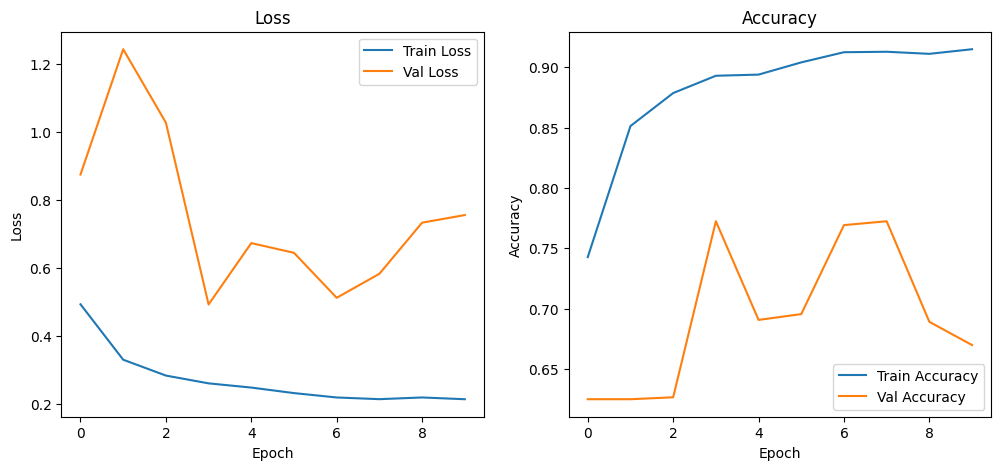

In [42]:
model.evaluate(validation_ds)

from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in validation_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.3).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.ravel())

classes = ["NORMAL", "PNEUMONIA"]

print(classification_report(y_true, y_pred, target_names=classes))

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#   ADJUSTING IMBALNACE BETWEEN DATASET
##   WEIGHT COMPUTER OF EACH CLASS

In [43]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from training generator
labels = np.concatenate([y.numpy() for _, y in training_ds])
print(labels)

class_weights_array = compute_class_weight(class_weight='balanced',
                                           classes=np.unique(labels), y=labels)

class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

history_weighted = model.fit(training_ds, validation_data=validation_ds, epochs=10,
                             class_weight=class_weights)

[1 0 1 ... 0 1 0]
Class Weights: {0: 1.939214232765011, 1: 0.6737058975019315}
Epoch 1/10
164/164 [==============================] - 19s 89ms/step - loss: 0.2359 - accuracy: 0.9071 - val_loss: 0.8658 - val_accuracy: 0.6651
Epoch 2/10
164/164 [==============================] - 18s 88ms/step - loss: 0.2265 - accuracy: 0.9113 - val_loss: 0.8191 - val_accuracy: 0.6923
Epoch 3/10
164/164 [==============================] - 19s 90ms/step - loss: 0.2245 - accuracy: 0.9098 - val_loss: 0.5016 - val_accuracy: 0.7869
Epoch 4/10
164/164 [==============================] - 19s 89ms/step - loss: 0.2218 - accuracy: 0.9119 - val_loss: 0.5411 - val_accuracy: 0.7644
Epoch 5/10
164/164 [==============================] - 19s 89ms/step - loss: 0.2103 - accuracy: 0.9193 - val_loss: 0.6285 - val_accuracy: 0.7901
Epoch 6/10
164/164 [==============================] - 19s 89ms/step - loss: 0.2145 - accuracy: 0.9142 - val_loss: 0.5044 - val_accuracy: 0.7837
Epoch 7/10
164/164 [==============================] - 19s

              precision    recall  f1-score   support

      NORMAL       0.53      0.93      0.68       234
   PNEUMONIA       0.93      0.51      0.66       390

    accuracy                           0.67       624
   macro avg       0.73      0.72      0.67       624
weighted avg       0.78      0.67      0.67       624



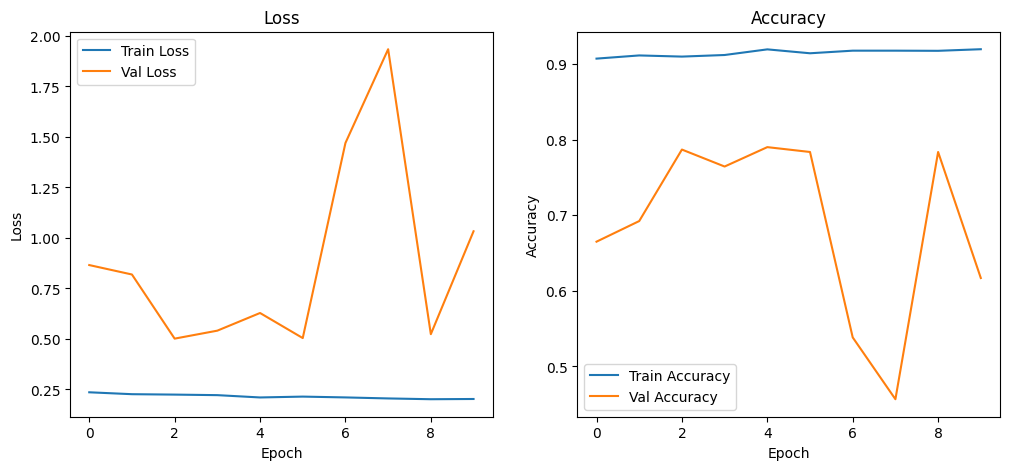

In [44]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in validation_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.3).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.ravel())

classes = ["NORMAL", "PNEUMONIA"]

print(classification_report(y_true, y_pred, target_names=classes))

plt.figure(figsize=(12, 5))
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['loss'], label='Train Loss')
plt.plot(history_weighted.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()